In this reading assignment, you will learn about the concepts of hyperparameter Search on a neural network.

## Prerequisites:
To start with hyperparameter Search, you must have knowledge about:
- Gradient Descents
- Cost Functions and backpropagations on a neural network

## Learning Objectives:
By the end of the lesson, all learners will be able to (minimum expected from everyone) :
- Revise on the rate of convergence of a neural network affected by the selection of learning rates  
- Use different approaches to searching for the best configuration of hyperparameters


### Cross Validation

Cross validation is the technique used to compare, test the effectiveness of the machine learning model. It is also used as resampling procedure, for training a model, and we don't train our model on entire dataset. We keep aside a sample of data which is not used for training the model. Then when training is finished, the sample data can be used for testing or validating the trained model.

In above section, the datasets are split into one set of training and one set of testing/validating data. They are only trained and tested once. So, the model may perform differently when they trained and tested in a different subset of the same dataset. To be able to train and test multiple times in different subsets of the same datasets and average performance of the models across multiple evaluations we use K-fold cross-validation.

In K-fold cross validation, we first split the dataset into training set and test set. The test set is used for the final evaluation of our model. The training set is spilt into k number of folds(subsets). This process is repeatd k times, the cross validation iterates through folds such that, one of the K fold is used as the test set and the remaining k-1 folds are put together to form a training set and then average the performance of the model with all folds and finalize the model. After that, we test it against the test set.

<center>
<figure>


<p>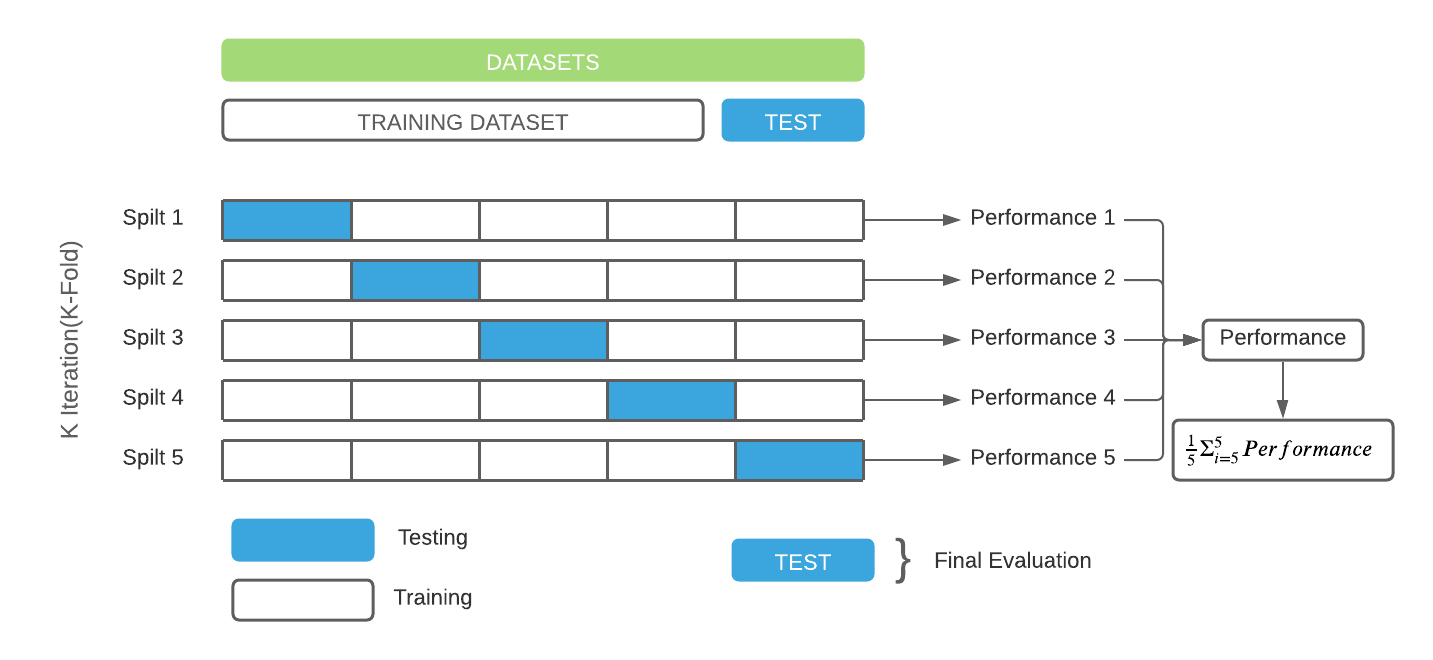</p>
<figcaption align="center">Figure 1: K-Fold Cross Validation</figcaption>
</figure>
</center>



### Grid Search

Grid Search is a search method in which the parameters are searched from a grid of a combination of a range of possible values. Generally, one parameter to be searched is in uniform gap in some pre-specified gap. If there is another parameter, each value of this parameter is combined with each value of previous parameter to form a grid like structure. Hence, we call this search method a grid search.

In hyperparameter search, we can use the same technique to search for the best hyperparameters. This can be determined by using metrics on test dataset. Thus, we can find the best model by searching through the hyperparameters in a grid.

#### Example: Grid Search of two hyperparameters

Let us use grid hyperparameter search for finding the hyperparameter of a neural network. Let us consider the two hyperparameters to be:
1. Learning Rate (lr)
2. Batch Size (bs)

Now, we can define the range of hyperparameters to search in. For Learning Rate, let us use values in the range [0.001, 0.00001]. For batch size, let us use values in the range [8, 1024]. Since the range is too large, we will use some gap between the parameters to be searched.

Let us use the learning rate in this range to produce 10 learning rates to try. Also, on the batch size, let us use all powers of 2 in the range.
The grid of the parameters look like below:



<p>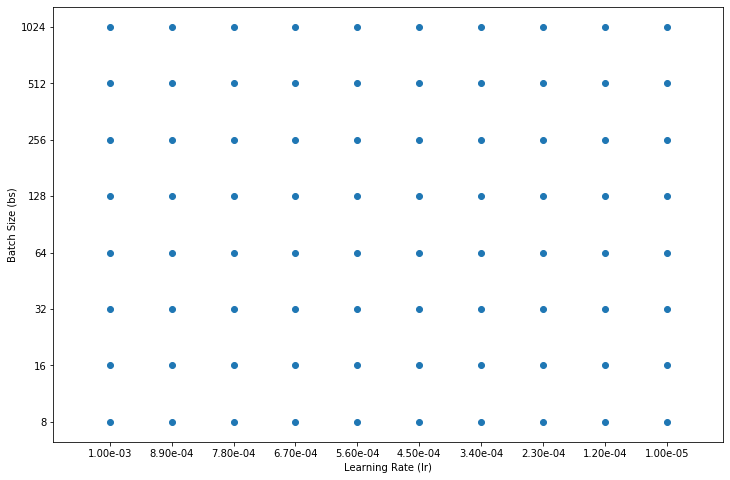</p>
<figcaption align="center">Figure 2: Grid Search</figcaption>


We then train our models with these values as hyperparameters and the one that performs best on test metrics is chosen as best model (and best hyperparameters). Similarly, grid search can be done for multiple hyperparameters.

The problem with grid search is that it takes a lot of time to try all the combinations. The larger the number of hyperparameters, the larger the time taken. The number of combinations increases drastically when one parameter is increased. Trying all the combinations then becomes infeasible for a large number of hyperparameters. Hence, this method is not generally used for hyperparameter tuning in deep neural networks with lots of hyperparameters.




### Random Search

Random Search is another search method where the parameters are sampled randomly from prespecified distribution such as uniform or gaussian distribution.

In Grid search, we search parameters in a grid like structure specified by combination of possible values of parameters. In Random Search, we randomly sample parameters from their possible distribution and use all randomly sampled parameters. Using random search gives us various hyperparameters to use in our models, but it does not try to cover all possible combinations of hyperparameters. Hence, we get variation in hyperparameters and can try to find the best model with those hyperparameters.

Let us use Random Search to find two hyperparameters, learning rate and batch size. Let us consider the learning rate to be in range [0.001, 0.00001]and batch size in range [8, 1024], distributed uniformly.

Sampling uniformly in the given ranges for 20 times, we get parameters as follows:



<p>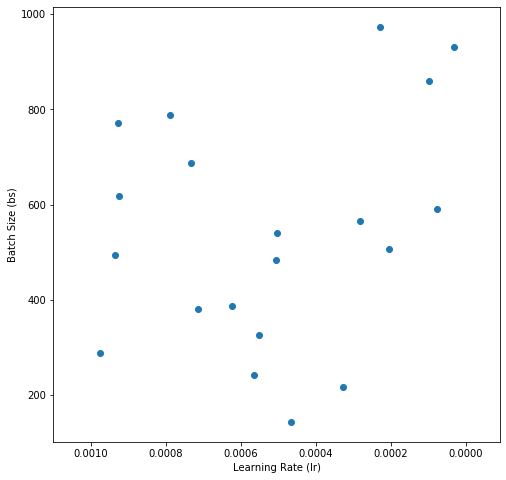</p>
<figcaption align="center">Figure 3: Random Search</figcaption>


If there are a large number of hyperparameters, we can benefit from randomly searching for hyperparameters. We can try various combinations of hyperparameters, and hence get various models with those hyperparameters. Although this method is beneficial to find best among the various randomly sampled hyperparameters, we cannot find the best possible hyperparameter. To find the best hyperparameter, we need to sample the hyperparameters a large number of times. This is infeasible when the model takes a long time to train and when there are large number of hyperparameters. Still, it is better than grid search in deep learning.








## Implementation of K-fold Cross Validation in Tensorflow




In [ ]:
# Import librabries
import tensorflow as tf
from keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import KFold
import numpy as np

In [ ]:
# Model Hyperparameters
batch_size = 256
classes = 10
no_of_epochs = 20
num_folds = 5

In [ ]:
# Data Preprocessing

# Load MNIST data
(X_train,y_train),(X_test,y_test) = mnist.load_data()

# Shape of input shape
X_train_shape = X_train.shape
X_test_shape = X_test.shape

# Keras Input shape
input_shape = (X_train_shape[1],X_train_shape[2])

# Parse number as floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Normalize data
X_train = X_train/255
X_test = X_test/255

11493376/11490434 [==============================] - 0s 0us/step


In [ ]:
def create_model():
  # Model Architecture
  model = Sequential([
      Flatten(input_shape = input_shape),
      Dense(units=128,activation='relu'),
      Dense(units=classes,activation='softmax')
  ])
  # Compile the model
  model.compile(optimizer='adam',loss='SparseCategoricalCrossentropy',metrics=['accuracy'])
  return model

In [ ]:
# Define per fold score list
acc_per_fold = []
loss_per_fold = []

In [ ]:
# Merge inputs and targets
inputs = np.concatenate((X_train,X_test))
targets = np.concatenate((y_train,y_test))

In [ ]:
# Define the k-fold cross validation
kfold = KFold(n_splits=num_folds,shuffle=True)

In [ ]:
# K-Fold Cross Validation Model Evaluation
fold_no =1
for train,test in kfold.split(inputs,targets):
  model = create_model()
  # Fit data to model
  history = model.fit(inputs[train],targets[train],epochs=no_of_epochs,batch_size=batch_size)

  # Generate generalization metrics
  scores=model.evaluate(inputs[test],targets[test],verbose=0)
  print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])

Epoch 1/20
219/219 [==============================] - 1s 4ms/step - loss: 0.4505 - accuracy: 0.8775
Epoch 2/20
219/219 [==============================] - 1s 4ms/step - loss: 0.2014 - accuracy: 0.9432
Epoch 3/20
219/219 [==============================] - 1s 4ms/step - loss: 0.1488 - accuracy: 0.9578
Epoch 4/20
219/219 [==============================] - 1s 4ms/step - loss: 0.1187 - accuracy: 0.9665
Epoch 5/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0978 - accuracy: 0.9722
Epoch 6/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0818 - accuracy: 0.9768
Epoch 7/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0691 - accuracy: 0.9806
Epoch 8/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0601 - accuracy: 0.9831
Epoch 9/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0525 - accuracy: 0.9854
Epoch 10/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0456 - accuracy: 0.9879

In [ ]:
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')

Average scores for all folds:
> Accuracy: 97.72571444511414 (+- 0.15156210637943815)
> Loss: 0.08183370530605316


##Implementation of Grid Search in Tensorflow(Keras)


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dropout, Input

In [ ]:
def create_model(optimizer='adam',dropout=0.1):
  model = Sequential([
            Flatten(input_shape=input_shape),
            Dense(units=64,activation='relu'),
            Dropout(rate=dropout),
            Dense(units=128,activation='relu'),
            Dense(units=10,activation='softmax')
  ])
  model.compile(optimizer=optimizer,loss='SparseCategoricalCrossentropy',metrics=['accuracy'])
  return model

To perform Grid Search with Sequential Keras models, we need to turn the models into sklearn-compatible estimators by wrapping them with the KerasClassifier or KerasRegressor class.

To use these wrappers, first we must define a function that creates and returns our Keras sequential model, then pass this function to the build_fn argument when constructing the KerasClassifier class.


In [ ]:
keras_estimator = KerasClassifier(build_fn=create_model,verbose=0,epochs=10)

In [ ]:
# define the grid search parameters
param_grid = {
    'optimizer':['sgd','adam','RMSprop','Adagrad'],
    'dropout':[0.1,0.2,0.25],
    'batch_size':[10,20,30,40],
}

In [ ]:
# Performing Grid Search with KFold Cross Validation

kfold_spilts = 5
grid = GridSearchCV(estimator= keras_estimator,
                    param_grid=param_grid,
                    cv=kfold_spilts,
                    return_train_score=True)

In [ ]:
grid_results = grid.fit(X_train,y_train)

In [ ]:
grid_results

GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=<tensorflow.python.keras.wrappers.scikit_learn.KerasClassifier object at 0x000001B4A1768B70>,
             iid='warn', n_jobs=None,
             param_grid={'batch_size': [10, 20, 30, 40],
                         'dropout': [0.1, 0.2, 0.25],
                         'optimizer': ['sgd', 'adam', 'RMSprop', 'Adagrad']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring=None, verbose=0)

In [ ]:
#best_score_  provides access to the best score observed during the optimization procedure
grid_results.best_score_

0.9731333255767822

In [ ]:
#best_params_ describes the combination of parameters that achieved the best results.
grid_results.best_params_

{'batch_size': 20, 'dropout': 0.1, 'optimizer': 'adam'}

## Implementation of Random Search in Tensorflow(Keras)


In [ ]:
# Performing Random Search with KFold Cross Validation

kfold_spilts = 5
random = RandomizedSearchCV(estimator = keras_estimator,
                            param_distributions= param_grid,
                            cv = kfold_spilts,
                            n_jobs = -1,
                            return_train_score = True)

In [ ]:
random_results = random.fit(X_train,y_train)

In [ ]:
random_results

RandomizedSearchCV(cv=5, error_score='raise-deprecating',
                   estimator=<tensorflow.python.keras.wrappers.scikit_learn.KerasClassifier object at 0x000001B4A1768B70>,
                   iid='warn', n_iter=10, n_jobs=-1,
                   param_distributions={'batch_size': [10, 20, 30, 40],
                                        'dropout': [0.1, 0.2, 0.25],
                                        'optimizer': ['sgd', 'adam', 'RMSprop',
                                                      'Adagrad']},
                   pre_dispatch='2*n_jobs', random_state=None, refit=True,
                   return_train_score=True, scoring=None, verbose=0)

In [ ]:
#best_score_  provides access to the best score observed during the optimization procedure
random_results.best_score_

0.9718666672706604

In [ ]:
#best_params_ describes the combination of parameters that achieved the best results.
random_results.best_params_

{'optimizer': 'adam', 'dropout': 0.1, 'batch_size': 20}

In this case, both grid search and random search perform really well in finding the best parameter but, even though they find the same best hyperparameter set, grid search take a lot of time to to try all the combinations from param grid. so, grid search is not generally used for hyperparameter tuning in deep neural networks with lots of hyperparameters.


##Implementation of K-fold Cross Validation in PyTorch




In [ ]:
# Import librabries
import numpy as np

import torch
from torch import nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset

from sklearn.model_selection import KFold

In [ ]:
# Model Hyperparameters
batch_size = 256
classes = 10
input_size = 28*28
no_of_epochs = 5
num_folds = 5

In [ ]:
# Get training device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
# Data Preprocessing

transform=transforms.Compose([
                              transforms.ToTensor(), # Read file and convert image to Tensor
                              transforms.Normalize(0, 1)
                              ])

# Load MNIST data
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

# Merge datasets to single one
all_dataset = ConcatDataset([training_data, test_data])

In [ ]:
def create_model():
  # Model Architecture
  model = nn.Sequential(
      nn.Flatten(),
      nn.Linear(input_size, 128),
      nn.ReLU(),
      nn.Linear(128, classes)
  )
  # Compile the model
  loss_func =  nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters())
  return model, loss_func, optimizer

In [ ]:
def train(dataloader, model, device, loss_func, optimizer):
    num_examples = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Put model in training mode
    model.train()

    # Initialize variable to store epoch loss and accuracy
    epoch_loss = 0
    epoch_correct = 0

    # Loops over the training data on batch
    for batch, (X, y) in enumerate(dataloader):
        # Copy data to device
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_func(pred, y)

        # Remove any previous gradient calculation done by optimizer
        optimizer.zero_grad()

        # Perform backward propagation
        loss.backward()

        # Perform gradient update
        optimizer.step()

        # Calculate accuracy
        epoch_correct += (pred.argmax(dim=-1) == y).sum().item()
        epoch_loss += loss.item()

    # return epoch avg loss and accuracy
    return epoch_loss/num_batches, epoch_correct/num_examples

In [ ]:
def evaluate(dataloader, model, device, loss_func):
    num_examples = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Put model in evalutation mode
    model.eval()

    # Initialize variable to store loss and accuracy
    test_loss = 0
    test_correct = 0

    # disable gadient calculation during evaluation
    with torch.no_grad():
        # Loops over the evaluation data on batch
        for batch, (X, y) in enumerate(dataloader):
            # Copy data to device
            X, y = X.to(device), y.to(device)

            # Compute prediction error
            pred = model(X)
            loss = loss_func(pred, y)

            # Calculate accuracy
            test_correct += (pred.argmax(dim=-1) == y).sum().item()
            test_loss += loss.item()

    # Eval metrics
    test_loss = test_loss/num_batches
    test_accuracy = test_correct/num_examples
    # return avg loss and accuracy
    return test_loss, test_accuracy

In [ ]:
# Define per fold score list
acc_per_fold = []
loss_per_fold = []

In [ ]:
# Define the k-fold cross validation
kfold = KFold(n_splits=num_folds,shuffle=True)

In [ ]:
# K-Fold Cross Validation Model Evaluation
for fold, (train_idxs, test_idxs) in enumerate(kfold.split(all_dataset)):
    print(f"__________fold no: {fold}_____________")

    # shuffle data indices
    train_set = torch.utils.data.dataset.Subset(all_dataset, train_idxs)
    eval_set = torch.utils.data.dataset.Subset(all_dataset, test_idxs)

    # Create data loader
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(
        eval_set,
        batch_size=batch_size)

    # Create artifacts
    model, loss_func, optimizer = create_model()
    model = model.to(device)

    # Train the model
    for ep in range(no_of_epochs):
        train(train_loader, model, device, loss_func, optimizer)

    # Evaluate model
    test_loss, test_accuracy = evaluate(test_loader, model, device, loss_func)

    # Generate generalization metrics
    print(f'Score for fold {fold}: Loss of {test_loss}; Accuracy of {test_accuracy*100}%')
    acc_per_fold.append(test_accuracy * 100)
    loss_per_fold.append(test_loss)

__________fold no: 0_____________
Score for fold 0: Loss of 0.09063148605213923; Accuracy of 97.36428571428571%
__________fold no: 1_____________
Score for fold 1: Loss of 0.08932497569105842; Accuracy of 97.43571428571428%
__________fold no: 2_____________
Score for fold 2: Loss of 0.06886239507320252; Accuracy of 98.0%
__________fold no: 3_____________
Score for fold 3: Loss of 0.08722981119697744; Accuracy of 97.32142857142857%
__________fold no: 4_____________
Score for fold 4: Loss of 0.08237811367620121; Accuracy of 97.65714285714286%


In [ ]:
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')

Average scores for all folds:
> Accuracy: 97.55571428571429 (+- 0.2504445027937172)
> Loss: 0.08368535633791577


##Implementation of Grid Search in Pytorch


To use gridsearch/random search from Sklearn we need to use Sklearn estimators. Unlike Keras, Pytorch doesn't have inbuilt sklearn wrappers for its model. So we will write our custom SK learn estimators compatible with PyTorch.


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class PyTorchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self,
                 optimizer='adam',
                 dropout=0.1,
                 batch_size=10,
                 epoch=5,
                 device=None,
                 **kwargs,
                 ):
        super(PyTorchClassifier, self).__init__(**kwargs)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') if device is None else device
        self.dropout = dropout
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        ).to(self.device)

        self.loss_func = nn.CrossEntropyLoss()

        self.optimizer = optimizer
        if self.optimizer == 'adam':
            self.optim = torch.optim.Adam(self.model.parameters())
        elif self.optimizer == 'sgd':
            self.optim = torch.optim.SGD(self.model.parameters(), lr=0.001)
        elif self.optimizer == 'RMSprop':
            self.optim == torch.optim.RMSprop(self.model.parameters())
        elif self.optimizer == 'Adagrad':
            self.optim = torch.optim.Adagrad(self.model.parameters())
        else:
            raise ValueError(f"optimizers allowed are {', '.join(['sgd','adam','RMSprop','Adagrad'])}")

        self.batch_size = batch_size
        self.epoch = epoch

    def fit(self, X, y):
        dataset = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        for ep in range(self.epoch):
            train(dataloader, self.model, self.device, self.loss_func, self.optim)
        return self

    def predict(self, X):
        dataset = torch.utils.data.TensorDataset(X)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size)

        self.model.eval()

        with torch.no_grad():
            predictions = torch.Tensor().to(self.device)
            for (inp, ) in dataloader:
                inp = inp.to(self.device)
                pred = self.model(inp)
                predictions = torch.concat([predictions, pred])
        return predictions.argmax(dim=-1).cpu()

pt_classifier = PyTorchClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV

# define the grid search parameters
param_grid = {
    'optimizer':['sgd','adam'],
    'dropout':[0.1,0.3],
    'batch_size':[64, 128, 256],
}

# Performing Grid Search with KFold Cross Validation

kfold_spilts = 5
grid = GridSearchCV(estimator= pt_classifier,
                    param_grid=param_grid,
                    cv=kfold_spilts,
                    verbose=4,
                    return_train_score=True)

In [ ]:
# Get all transformed training dataset as a tensor because SKlearn doesn't support pytorch dataloader
X_train, y_train = next(iter(torch.utils.data.DataLoader(training_data, batch_size=len(training_data))))

In [ ]:
grid_results = grid.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END batch_size=64, dropout=0.1, optimizer=sgd;, score=(train=0.980, test=0.967) total time=  10.7s
[CV 2/5] END batch_size=64, dropout=0.1, optimizer=sgd;, score=(train=0.981, test=0.967) total time=  15.7s
[CV 3/5] END batch_size=64, dropout=0.1, optimizer=sgd;, score=(train=0.980, test=0.964) total time=  10.8s
[CV 4/5] END batch_size=64, dropout=0.1, optimizer=sgd;, score=(train=0.981, test=0.962) total time=  10.7s
[CV 5/5] END batch_size=64, dropout=0.1, optimizer=sgd;, score=(train=0.981, test=0.969) total time=  10.8s
[CV 1/5] END batch_size=64, dropout=0.1, optimizer=adam;, score=(train=0.977, test=0.964) total time=  10.7s
[CV 2/5] END batch_size=64, dropout=0.1, optimizer=adam;, score=(train=0.981, test=0.966) total time=  10.7s
[CV 3/5] END batch_size=64, dropout=0.1, optimizer=adam;, score=(train=0.982, test=0.966) total time=  10.8s
[CV 4/5] END batch_size=64, dropout=0.1, optimizer=adam;, score=(train=0

In [ ]:
#best_score_  provides access to the best score observed during the optimization procedure
grid_results.best_score_

0.9674833333333334

In [ ]:
#best_params_ describes the combination of parameters that achieved the best results.
grid_results.best_params_

{'batch_size': 64, 'dropout': 0.3, 'optimizer': 'adam'}

##Implementation of Random Search in PyTorch


In [ ]:
# Performing Random Search with KFold Cross Validation
from sklearn.model_selection import RandomizedSearchCV

# define the search parameters
param_grid = {
    'optimizer':['sgd','adam','RMSprop','Adagrad'],
    'dropout':[0.1,0.2,0.25],
    'batch_size':[32,64,128,256],
}

kfold_spilts = 5
random = RandomizedSearchCV(estimator = pt_classifier,
                            param_distributions= param_grid,
                            cv = kfold_spilts,
                            verbose=4,
                            return_train_score = True)

In [ ]:
random_results = random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END batch_size=64, dropout=0.2, optimizer=sgd;, score=(train=0.980, test=0.969) total time=  11.9s
[CV 2/5] END batch_size=64, dropout=0.2, optimizer=sgd;, score=(train=0.981, test=0.966) total time=  10.6s
[CV 3/5] END batch_size=64, dropout=0.2, optimizer=sgd;, score=(train=0.982, test=0.965) total time=  10.6s
[CV 4/5] END batch_size=64, dropout=0.2, optimizer=sgd;, score=(train=0.983, test=0.964) total time=  10.7s
[CV 5/5] END batch_size=64, dropout=0.2, optimizer=sgd;, score=(train=0.980, test=0.968) total time=  10.8s
[CV 1/5] END batch_size=64, dropout=0.2, optimizer=RMSprop;, score=(train=0.982, test=0.971) total time=  10.7s
[CV 2/5] END batch_size=64, dropout=0.2, optimizer=RMSprop;, score=(train=0.981, test=0.965) total time=  10.7s
[CV 3/5] END batch_size=64, dropout=0.2, optimizer=RMSprop;, score=(train=0.981, test=0.965) total time=  11.4s
[CV 4/5] END batch_size=64, dropout=0.2, optimizer=RMSprop;, sc

In [ ]:
random_results

RandomizedSearchCV(cv=5,
                   estimator=PyTorchClassifier(device=device(type='cuda')),
                   param_distributions={'batch_size': [32, 64, 128, 256],
                                        'dropout': [0.1, 0.2, 0.25],
                                        'optimizer': ['sgd', 'adam', 'RMSprop',
                                                      'Adagrad']},
                   return_train_score=True, verbose=4)

In [ ]:
#best_score_  provides access to the best score observed during the optimization procedure
random_results.best_score_

0.96905

In [ ]:
#best_params_ describes the combination of parameters that achieved the best results.
random_results.best_params_

{'batch_size': 32, 'dropout': 0.1, 'optimizer': 'sgd'}

In this case, both grid search and random search perform really well in finding the best parameter but, even though they find the same best hyperparameter set, grid search take a lot of time to to try all the combinations from param grid. so, grid search is not generally used for hyperparameter tuning in deep neural networks with lots of hyperparameters.


## Key Takeaways

* Cross-validation is used to test effectiveness, compare and select a model
* Grid Search is a search method in which the parameters are searched from a grid of combination of a range of possible values
* Random Search is a search method where the parameters are sampled randomly from a prespecified distribution such as uniform or gaussian distribution.

